In [35]:
#Loretta O. Cruz
#BIOINFORMATICS
#Cat Dog CNN Hyperparameter Tuning

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [9]:
import os

dataset_path = os.path.expanduser("~/Desktop/PetImages")

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

print("Dataset path:", dataset_path)
print("Cat folder exists:", os.path.exists(cat_path))
print("Dog folder exists:", os.path.exists(dog_path))

Dataset path: /Users/lorettacruz/Desktop/PetImages
Cat folder exists: True
Dog folder exists: True


In [10]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

IMG_SIZE = 150

X = []
y = []

# Load Cat images
...
# Load Dog images
...

Ellipsis

In [11]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

IMG_SIZE = 150

# Limit images to avoid memory problem
MAX_IMAGES_PER_CLASS = 3000

X = []
y = []

# =========================
# LOAD CAT IMAGES
# =========================

cat_files = [
    f for f in os.listdir(cat_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for filename in cat_files[:MAX_IMAGES_PER_CLASS]:
    try:
        img = load_img(
            os.path.join(cat_path, filename),
            target_size=(IMG_SIZE, IMG_SIZE)
        )

        img = img_to_array(img)

        X.append(img)
        y.append(0)  # Cat = 0

    except:
        pass


# =========================
# LOAD DOG IMAGES
# =========================

dog_files = [
    f for f in os.listdir(dog_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for filename in dog_files[:MAX_IMAGES_PER_CLASS]:
    try:
        img = load_img(
            os.path.join(dog_path, filename),
            target_size=(IMG_SIZE, IMG_SIZE)
        )

        img = img_to_array(img)

        X.append(img)
        y.append(1)  # Dog = 1

    except:
        pass


# =========================
# CONVERT TO NUMPY ARRAYS
# =========================

X = np.array(X, dtype="float32") / 255.0
y = np.array(y, dtype="float32")

print("X shape:", X.shape)
print("y shape:", y.shape)

/opt/anaconda3/envs/cnn/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


X shape: (6000, 150, 150, 3)
y shape: (6000,)


In [12]:
import os

dataset_path = os.path.expanduser("~/Desktop/PetImages")

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

print("Dataset path:", dataset_path)
print("Cat folder exists:", os.path.exists(cat_path))
print("Dog folder exists:", os.path.exists(dog_path))

Dataset path: /Users/lorettacruz/Desktop/PetImages
Cat folder exists: True
Dog folder exists: True


In [13]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

IMG_SIZE = 150
MAX_IMAGES_PER_CLASS = 3000

X = []
y = []

# =========================
# LOAD CAT IMAGES
# =========================

cat_files = [
    f for f in os.listdir(cat_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for filename in cat_files[:MAX_IMAGES_PER_CLASS]:
    try:
        img = load_img(
            os.path.join(cat_path, filename),
            target_size=(IMG_SIZE, IMG_SIZE)
        )
        img = img_to_array(img)

        X.append(img)
        y.append(0)

    except:
        pass


# =========================
# LOAD DOG IMAGES
# =========================

dog_files = [
    f for f in os.listdir(dog_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for filename in dog_files[:MAX_IMAGES_PER_CLASS]:
    try:
        img = load_img(
            os.path.join(dog_path, filename),
            target_size=(IMG_SIZE, IMG_SIZE)
        )
        img = img_to_array(img)

        X.append(img)
        y.append(1)

    except:
        pass


# =========================
# CONVERT TO NUMPY ARRAYS
# =========================

X = np.array(X, dtype="float32") / 255.0
y = np.array(y, dtype="float32")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6000, 150, 150, 3)
y shape: (6000,)


In [14]:
import sys

print(sys.executable)

/opt/anaconda3/envs/cnn/bin/python


In [15]:
import sys
!{sys.executable} -m pip install keras-tuner

In [12]:
import sys

print(sys.executable)

/opt/anaconda3/envs/cnn/bin/python


In [13]:
import keras_tuner as kt

print("Keras Tuner version:", kt.__version__)

Keras Tuner version: 1.4.8


In [16]:
import tensorflow as tf

def build_tuned_model(hp):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=X.shape[1:]))

    # Number of convolutional layers
    num_conv_layers = hp.Int(
        "num_conv_layers",
        min_value=2,
        max_value=4,
        step=1
    )

    # Convolutional layers
    for i in range(num_conv_layers):

        filters = hp.Choice(
            f"filters_{i}",
            values=[32, 64, 128]
        )

        model.add(
            tf.keras.layers.Conv2D(
                filters=filters,
                kernel_size=(3, 3),
                activation="relu"
            )
        )

        model.add(
            tf.keras.layers.MaxPooling2D(
                pool_size=(2, 2)
            )
        )

    # Fully connected layer
    model.add(tf.keras.layers.Flatten())

    dense_units = hp.Int(
        "dense_units",
        min_value=128,
        max_value=512,
        step=128
    )

    model.add(
        tf.keras.layers.Dense(
            dense_units,
            activation="relu"
        )
    )

    # Dropout
    dropout = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.5,
        step=0.1
    )

    model.add(
        tf.keras.layers.Dropout(dropout)
    )

    # Output
    model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    # Learning rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-2, 1e-3, 1e-4]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
import keras_tuner as kt

tuner = kt.Hyperband(
    build_tuned_model,
    objective="val_accuracy",
    max_epochs=10,
    factor=3,
    directory="keras_tuner_cats_dogs",
    project_name="cats_vs_dogs",
    overwrite=True
)

print("Hyperband tuner created successfully!")

Hyperband tuner created successfully!


In [18]:
tuner.search_space_summary()

Search space summary
Default search space size: 6
num_conv_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
filters_0 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
filters_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 128, 'sampling': 'linear'}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [19]:
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tuner.search(
    X,
    y,
    validation_split=0.10,
    batch_size=32,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)

Trial 30 Complete [00h 05m 30s]

Best val_accuracy So Far: 0.8700000047683716
Total elapsed time: 02h 27m 14s


In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [20]:
tuner.results_summary()

Results summary
Results in keras_tuner_cats_dogs/cats_vs_dogs
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0024 summary
Hyperparameters:
num_conv_layers: 3
filters_0: 32
filters_1: 128
dense_units: 128
dropout: 0.30000000000000004
learning_rate: 0.0001
filters_2: 128
filters_3: 32
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0020
Score: 0.8700000047683716

Trial 0026 summary
Hyperparameters:
num_conv_layers: 3
filters_0: 64
filters_1: 64
dense_units: 256
dropout: 0.30000000000000004
learning_rate: 0.0001
filters_2: 128
filters_3: 128
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.8100000023841858

Trial 0020 summary
Hyperparameters:
num_conv_layers: 3
filters_0: 32
filters_1: 128
dense_units: 128
dropout: 0.30000000000000004
learning_rate: 0.0001
filters_2: 128
filters_3: 32
tuner/epochs: 4
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.7749999761581421

Trial 

In [21]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("BEST HYPERPARAMETERS")
for key, value in best_hp.values.items():
    print(f"{key}: {value}")

BEST HYPERPARAMETERS
num_conv_layers: 3
filters_0: 32
filters_1: 128
dense_units: 128
dropout: 0.30000000000000004
learning_rate: 0.0001
filters_2: 128
filters_3: 32
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0020


In [22]:
best_model = tuner.get_best_models(num_models=1)[0]

print("Best model loaded successfully!")
best_model.summary()

Best model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,920,705 (18.77 MB)

 Trainable params: 4,920,705 (18.77 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_best = best_model.fit(
    X,
    y,
    validation_split=0.10,
    batch_size=32,
    epochs=20,
    callbacks=[stop_early],
    verbose=1
)

Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 63s 364ms/step - accuracy: 0.8250 - loss: 0.3945 - val_accuracy: 0.6683 - val_loss: 0.6224
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 66s 387ms/step - accuracy: 0.8320 - loss: 0.3785 - val_accuracy: 0.6950 - val_loss: 0.5775
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 68s 400ms/step - accuracy: 0.8428 - loss: 0.3608 - val_accuracy: 0.8000 - val_loss: 0.4338
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 69s 407ms/step - accuracy: 0.8524 - loss: 0.3420 - val_accuracy: 0.8533 - val_loss: 0.3586
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 70s 412ms/step - accuracy: 0.8639 - loss: 0.3188 - val_accuracy: 0.8117 - val_loss: 0.4225
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 73s 431ms/step - accuracy: 0.8774 - loss: 0.2957 - val_accuracy: 0.7333 - val_loss: 0.5764
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 72s 424ms/step - accuracy: 0.8850 - loss: 0.2819 - val_accuracy: 0.7767 - val_loss: 0.4957


In [24]:
print("Training completed epochs:", len(history_best.history["accuracy"]))
print("Best training accuracy:", max(history_best.history["accuracy"]))
print("Best validation accuracy:", max(history_best.history["val_accuracy"]))

Training completed epochs: 7
Best training accuracy: 0.8849999904632568
Best validation accuracy: 0.8533333539962769


In [25]:
print("FINAL TUNING RESULTS")
print("====================")

print("Best Hyperparameters:")
print("Number of Conv Layers:", best_hp.get("num_conv_layers"))
print("Filters Layer 1:", best_hp.get("filters_0"))
print("Filters Layer 2:", best_hp.get("filters_1"))
print("Filters Layer 3:", best_hp.get("filters_2"))
print("Dense Units:", best_hp.get("dense_units"))
print("Dropout:", best_hp.get("dropout"))
print("Learning Rate:", best_hp.get("learning_rate"))

print("\nPerformance:")
print("Best Training Accuracy:",
      max(history_best.history["accuracy"]))
print("Best Validation Accuracy:",
      max(history_best.history["val_accuracy"]))

FINAL TUNING RESULTS
Best Hyperparameters:
Number of Conv Layers: 3
Filters Layer 1: 32
Filters Layer 2: 128
Filters Layer 3: 128
Dense Units: 128
Dropout: 0.30000000000000004
Learning Rate: 0.0001

Performance:
Best Training Accuracy: 0.8849999904632568
Best Validation Accuracy: 0.8533333539962769


In [26]:
print("========================================")
print("MANUAL CNN vs KERAS TUNER")
print("========================================")

manual_val_accuracy = 0.8522   # change this if your actual manual result is different
tuned_val_accuracy = max(history_best.history["val_accuracy"])

improvement = tuned_val_accuracy - manual_val_accuracy

print(f"Manual CNN Validation Accuracy: {manual_val_accuracy:.4f} ({manual_val_accuracy*100:.2f}%)")
print(f"KerasTuner Validation Accuracy: {tuned_val_accuracy:.4f} ({tuned_val_accuracy*100:.2f}%)")
print(f"Improvement: {improvement:.4f} ({improvement*100:.2f} percentage points)")

MANUAL CNN vs KERAS TUNER
Manual CNN Validation Accuracy: 0.8522 (85.22%)
KerasTuner Validation Accuracy: 0.8533 (85.33%)
Improvement: 0.0011 (0.11 percentage points)


In [27]:
manual_val_accuracy = 0.8552
tuner_best_trial_accuracy = 0.8700
final_tuned_accuracy = max(history_best.history["val_accuracy"])

print("========================================")
print("FINAL MODEL COMPARISON")
print("========================================")

print(f"Manual CNN Validation Accuracy: {manual_val_accuracy*100:.2f}%")
print(f"KerasTuner Best Trial Accuracy: {tuner_best_trial_accuracy*100:.2f}%")
print(f"Final Tuned Model Accuracy: {final_tuned_accuracy*100:.2f}%")

print()
print(f"Best Trial Improvement: {(tuner_best_trial_accuracy-manual_val_accuracy)*100:.2f} percentage points")
print(f"Final Model Difference: {(final_tuned_accuracy-manual_val_accuracy)*100:.2f} percentage points")

FINAL MODEL COMPARISON
Manual CNN Validation Accuracy: 85.52%
KerasTuner Best Trial Accuracy: 87.00%
Final Tuned Model Accuracy: 85.33%

Best Trial Improvement: 1.48 percentage points
Final Model Difference: -0.19 percentage points


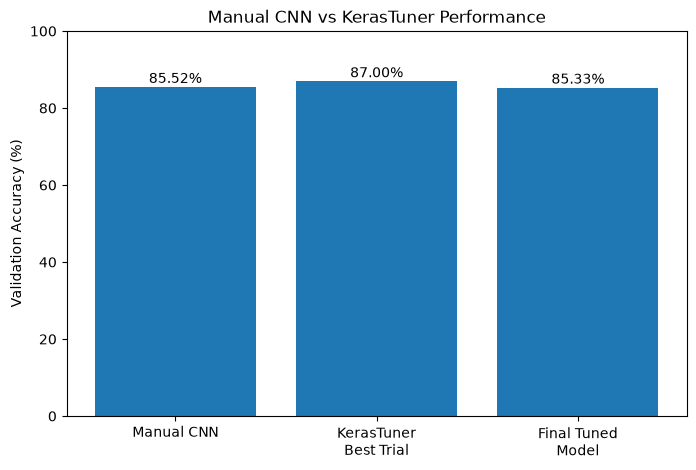

In [28]:
import matplotlib.pyplot as plt

models = [
    "Manual CNN",
    "KerasTuner\nBest Trial",
    "Final Tuned\nModel"
]

accuracies = [
    manual_val_accuracy * 100,
    tuner_best_trial_accuracy * 100,
    final_tuned_accuracy * 100
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

plt.ylabel("Validation Accuracy (%)")
plt.title("Manual CNN vs KerasTuner Performance")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

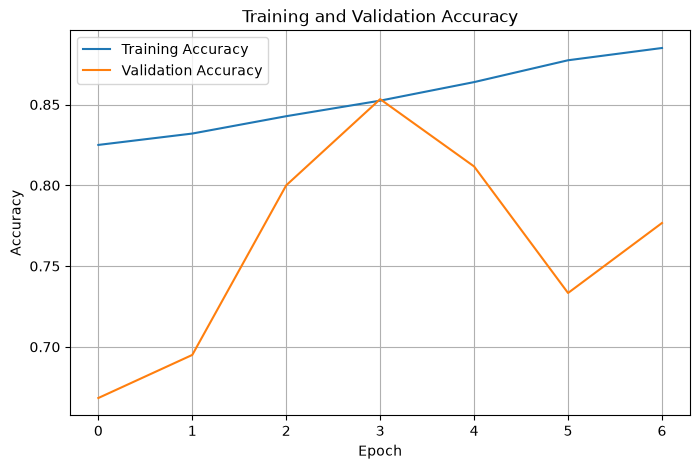

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_best.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_best.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

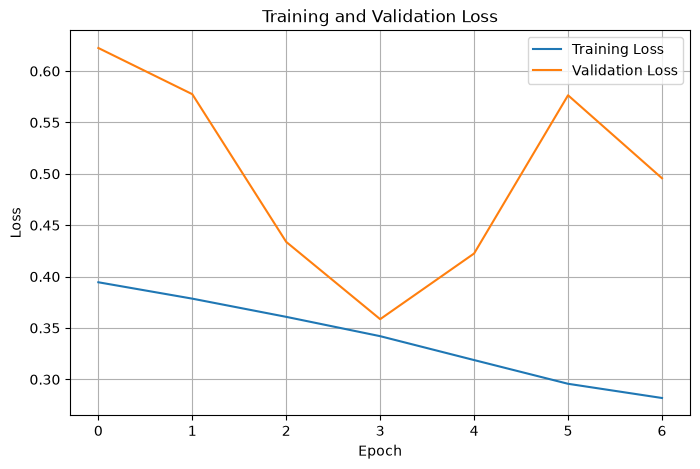

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_best.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_best.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
# ============================================================
# FINAL RESULTS AND CONCLUSION
# ============================================================

# HYPERPARAMETER TUNING RESULTS
#
# KerasTuner Hyperband was used to automatically search
# for the best CNN hyperparameters for the Cats and Dogs
# image classification task.
#
# Best Hyperparameters:
# Number of Convolutional Layers: 3
# Filters: 32, 128, 128
# Dense Units: 128
# Dropout: 0.30
# Learning Rate: 0.0001
#
# Best KerasTuner Trial Validation Accuracy: 87.00%
# Manual CNN Validation Accuracy: 85.52%
# Improvement: 1.48 percentage points
#
# Final Retrained Tuned Model Validation Accuracy: 85.33%
# Training stopped at Epoch 7 due to EarlyStopping.
#
# CONCLUSION:
#
# The results demonstrate that automated hyperparameter
# tuning can identify a CNN configuration that performs
# better than the manually configured baseline during the
# hyperparameter search.
#
# The best KerasTuner trial achieved 87.00% validation
# accuracy compared with 85.52% for the manual CNN,
# resulting in a 1.48 percentage-point improvement.
#
# The selected configuration used three convolutional
# layers, filters of 32, 128, and 128, 128 dense units,
# 30% dropout, and a learning rate of 0.0001.
#
# These results show that systematic hyperparameter
# optimization can help identify an effective CNN
# architecture without relying entirely on manual
# trial-and-error.

In [18]:
!pip install tensorboard

  Using cached tensorboard-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.21.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorboard] 1/2 [tensorboard]


In [2]:
import sys
!{sys.executable} -m pip install tensorboard

  Using cached tensorboard-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached markdown-3.11-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.9-py3-none-any.whl.metadata (4.1 kB)
  Using cached markupsafe-3.0.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached tensorboard-2.21.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
Using cached markdown-3.11-py3-none-any.whl (111 kB)
Using cached werkzeug-3.1.9-py3-none-any.whl (228 kB)
Using cached markupsafe-3.0.4-cp312-cp312-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [tensorboard] 4/5 [tensorboard]


In [1]:
import tensorboard
print("TensorBoard version:", tensorboard.__version__)

TensorBoard version: 2.21.0


In [4]:
import keras_tuner as kt
print("Keras Tuner version:", kt.__version__)

Keras Tuner version: 1.4.8
